# 06 - Evaluation

Đánh giá model trên tập **test** (606 ảnh, chưa từng thấy khi train/val) từ `data/processed/`.

**Checkpoint hiện tại**: `outputs/checkpoints/best.pt` - đây là checkpoint **tạm 2-epoch smoke test**
(xem `reports/training_report.md`), chưa phải kết quả full training thật. Kết quả evaluation ở notebook
này vì vậy chỉ mang tính minh hoạ pipeline - cần chạy lại notebook này sau khi full training xong (file
checkpoint sẽ tự động được thay bằng bản thật, không cần sửa code).

Nội dung: (1) metric tổng quan (P/R/mAP) qua `model.val()`, (2) **error analysis theo kích thước bbox**
- quan trọng vì đã đổi `imgsz` 1280→640 (xem `docs/architecture.md`), cần biết ảnh hưởng thực tế lên
khả năng phát hiện người nhỏ/xa, (3) ảnh mẫu so sánh ground truth vs prediction.

## 0. Setup

Load `configs/inference.yaml` (checkpoint, threshold), `configs/dataset.yaml` (resolution gốc để denormalize GT bbox).

In [1]:
import os
import sys
import random

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

sys.path.insert(0, os.path.abspath(".."))
from src.evaluation.statistics import match_predictions_to_gt, recall_by_size_bucket
from src.evaluation.visualize import draw_boxes

with open("../configs/inference.yaml", encoding="utf-8") as f:
    infer_cfg = yaml.safe_load(f)
with open("../configs/dataset.yaml", encoding="utf-8") as f:
    dataset_cfg = yaml.safe_load(f)

IMG_W, IMG_H = dataset_cfg["image"]["resolution"]
checkpoint_path = os.path.abspath(os.path.join("..", infer_cfg["checkpoint"]))
data_yaml_path = os.path.abspath("../data/processed/data.yaml")
test_images_dir = os.path.abspath("../data/processed/images/test")
test_labels_dir = os.path.abspath("../data/processed/labels/test")
device = 0 if torch.cuda.is_available() else "cpu"

model = YOLO(checkpoint_path)
print("Checkpoint:", checkpoint_path)
print("Classes:", model.names)
print("conf_threshold:", infer_cfg["conf_threshold"], "| iou_threshold:", infer_cfg["iou_threshold"])
print("Test set:", test_images_dir)

Checkpoint: D:\Thermal_project\outputs\checkpoints\best.pt
Classes: {0: 'Human'}
conf_threshold: 0.15 | iou_threshold: 0.45
Test set: D:\Thermal_project\data\processed\images\test


## 1. Metric tổng quan trên tập test

Dùng `model.val()` chuẩn của ultralytics - tự tính Precision, Recall, mAP50, mAP50-95, confusion matrix
(lưu plot tại thư mục `project/name` bên dưới).

In [2]:
val_metrics = model.val(
    data=data_yaml_path,
    split="test",
    imgsz=infer_cfg["image_size"][0],
    conf=infer_cfg["conf_threshold"],
    iou=infer_cfg["iou_threshold"],
    device=device,
    project=os.path.abspath("../outputs/logs"),
    name="eval_test",
    exist_ok=True,
    verbose=True,
)

print("\nPrecision:", val_metrics.box.p[0])
print("Recall:", val_metrics.box.r[0])
print("mAP50:", val_metrics.box.map50)
print("mAP50-95:", val_metrics.box.map)

Ultralytics 8.4.98  Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 1469.2459.5 MB/s, size: 211.4 KB)


val: Scanning D:\Thermal_project\data\processed\labels\test.cache... 606 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 606/606  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 2% ──────────── 1/38 2.0s/it 0.6s<1:14

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 5.9it/s 6.5s

                   all        606        904      0.967      0.973      0.968      0.597


Speed: 1.5ms preprocess, 5.5ms inference, 0.0ms loss, 0.8ms postprocess per image


Results saved to D:\Thermal_project\outputs\logs\eval_test



Precision: 0.9666948099493331
Recall: 0.9734513274336283
mAP50: 0.9683584857033678
mAP50-95: 0.5966311879348454


## 2. Error analysis theo kích thước bbox

`model.val()` ở trên cho mAP tổng quát, không cho biết model yếu ở nhóm kích thước nào. Ở đây tự chạy
`predict` trên từng ảnh test, đối chiếu (IoU matching) prediction với ground truth gốc (toạ độ pixel theo
resolution gốc 1280x960 - không phụ thuộc `imgsz` lúc train), rồi tính recall riêng theo từng nhóm kích
thước bbox (chia theo tứ phân vị thực tế của tập test) - mục tiêu là xem đổi `imgsz` 1280→640 có làm giảm
recall ở nhóm bbox nhỏ (người ở xa) hay không.

In [3]:
def load_gt_boxes(label_path):
    """Doc file YOLO .txt, tra ve list (x1,y1,x2,y2) pixel + list sqrt(area) theo resolution goc."""
    boxes, sqrt_areas = [], []
    if not os.path.isfile(label_path):
        return boxes, sqrt_areas
    with open(label_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            _, xc, yc, w, h = line.split()
            xc, yc, w, h = float(xc) * IMG_W, float(yc) * IMG_H, float(w) * IMG_W, float(h) * IMG_H
            boxes.append((xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2))
            sqrt_areas.append((w * h) ** 0.5)
    return boxes, sqrt_areas


test_images = sorted(f for f in os.listdir(test_images_dir) if f.lower().endswith((".jpg", ".jpeg")))
print(f"So anh test: {len(test_images)}")

So anh test: 606


In [4]:
records = []  # {"sqrt_area": float, "matched": bool} cho tung GT box

pred_stream = model.predict(
    source=test_images_dir,
    imgsz=infer_cfg["image_size"][0],
    conf=infer_cfg["conf_threshold"],
    iou=infer_cfg["iou_threshold"],
    device=device,
    stream=True,
    verbose=False,
)

for result in pred_stream:
    stem = os.path.splitext(os.path.basename(result.path))[0]
    label_path = os.path.join(test_labels_dir, stem + ".txt")
    gt_boxes, gt_sqrt_areas = load_gt_boxes(label_path)
    if not gt_boxes:
        continue

    pred_boxes = result.boxes.xyxy.cpu().numpy().tolist()  # da o toa do anh goc (ultralytics tu rescale)
    matched = match_predictions_to_gt(gt_boxes, pred_boxes, iou_threshold=0.5)

    for sqrt_area, is_matched in zip(gt_sqrt_areas, matched):
        records.append({"sqrt_area": sqrt_area, "matched": is_matched})

print(f"Tong so GT box da doi chieu: {len(records)}")
overall_recall = sum(r["matched"] for r in records) / len(records)
print(f"Recall tong the (IoU>=0.5, tinh tay - de doi chieu voi model.val() o tren): {overall_recall:.3f}")

Tong so GT box da doi chieu: 904
Recall tong the (IoU>=0.5, tinh tay - de doi chieu voi model.val() o tren): 0.979


Recall theo nhom kich thuoc bbox (sqrt-area px, chia theo tu phan vi thuc te cua test set):
  [   0.0 -   40.0) px: n= 226  recall=0.969
  [  40.0 -   51.3) px: n= 226  recall=0.987
  [  51.3 -   74.6) px: n= 226  recall=0.965
  [  74.6 -  227.7) px: n= 226  recall=0.996


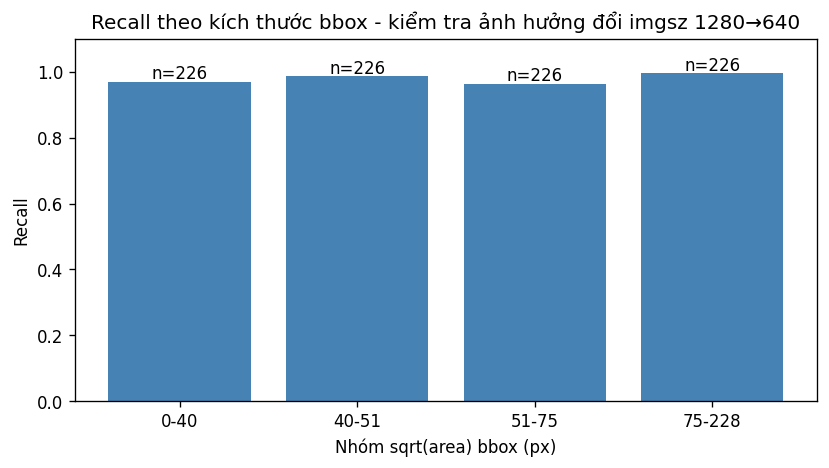

In [5]:
sqrt_areas = np.array([r["sqrt_area"] for r in records])
q25, q50, q75 = np.percentile(sqrt_areas, [25, 50, 75])
bucket_edges = [0, q25, q50, q75, sqrt_areas.max() + 1]

buckets = recall_by_size_bucket(records, bucket_edges)

print("Recall theo nhom kich thuoc bbox (sqrt-area px, chia theo tu phan vi thuc te cua test set):")
for (lo, hi), stats in buckets.items():
    print(f"  [{lo:6.1f} - {hi:6.1f}) px: n={stats['n']:4d}  recall={stats['recall']:.3f}")

labels = [f"{lo:.0f}-{hi:.0f}" for lo, hi in buckets]
recalls = [stats["recall"] for stats in buckets.values()]
counts = [stats["n"] for stats in buckets.values()]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, recalls, color="steelblue")
for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"n={n}", ha="center")
ax.set_xlabel("Nhóm sqrt(area) bbox (px)")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.1)
ax.set_title("Recall theo kích thước bbox - kiểm tra ảnh hưởng đổi imgsz 1280→640")
plt.tight_layout()

fig_path = os.path.abspath("../reports/figures/06_recall_by_bbox_size.png")
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.close(fig)

# model.val() o tren da chuyen matplotlib sang backend khong tuong tac (Agg) de tu ve
# confusion matrix/PR curve -> plt.show() sau do khong hien anh trong notebook duoc nua.
# Doc lai file da luu va hien qua IPython.display de dam bao anh luon hien thi dung.
from IPython.display import Image as IPImage, display
display(IPImage(filename=fig_path))

## 3. Ảnh mẫu: ground truth vs prediction

Xanh lá = ground truth, đỏ = prediction. Kiểm tra trực quan các trường hợp lệch/miss.

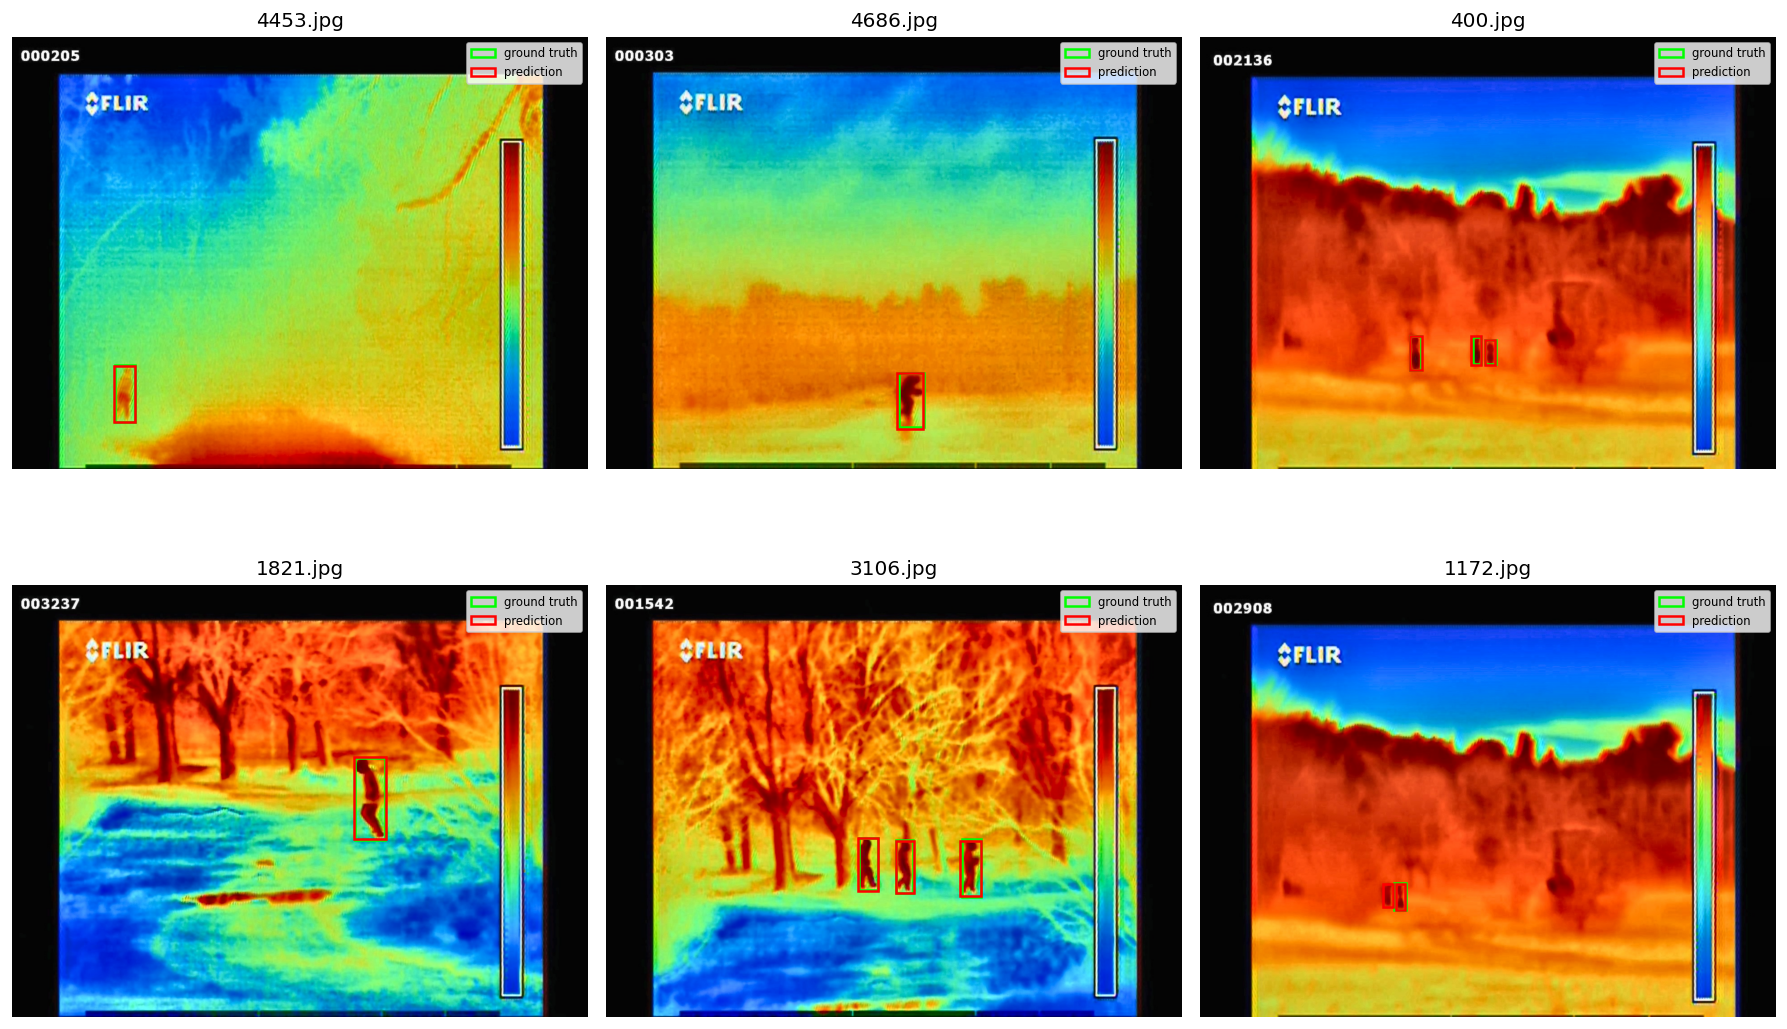

In [6]:
sample_images = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, jpg in zip(axes.flat, sample_images):
    img_path = os.path.join(test_images_dir, jpg)
    stem = os.path.splitext(jpg)[0]
    gt_boxes, _ = load_gt_boxes(os.path.join(test_labels_dir, stem + ".txt"))

    result = model.predict(source=img_path, imgsz=infer_cfg["image_size"][0],
                            conf=infer_cfg["conf_threshold"], iou=infer_cfg["iou_threshold"],
                            device=device, verbose=False)[0]
    pred_boxes = result.boxes.xyxy.cpu().numpy().tolist()

    ax.imshow(Image.open(img_path))
    draw_boxes(ax, gt_boxes, "lime", label="ground truth")
    draw_boxes(ax, pred_boxes, "red", label="prediction")
    ax.set_title(jpg)
    ax.legend(loc="upper right", fontsize=7)
    ax.axis("off")
plt.tight_layout()

fig_path = os.path.abspath("../reports/figures/06_sample_predictions.png")
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.close(fig)

from IPython.display import Image as IPImage, display
display(IPImage(filename=fig_path))

## 4. Tóm tắt

In [7]:
print("=" * 60)
print("TÓM TẮT EVALUATION")
print("=" * 60)
print(f"Checkpoint: {checkpoint_path} (TẠM - 2 epoch smoke test, chưa phải full training)")
print(f"Test set: {len(test_images)} ảnh")
print(f"Precision: {val_metrics.box.p[0]:.3f} | Recall: {val_metrics.box.r[0]:.3f}")
print(f"mAP50: {val_metrics.box.map50:.3f} | mAP50-95: {val_metrics.box.map:.3f}")
print(f"Recall theo kích thước bbox: xem biểu đồ ở mục 2")
print()
print("=> Chạy lại notebook này sau khi full training thật xong (05_training.ipynb,")
print("   RUN_FULL_TRAINING=True) để có kết quả evaluation chính xác.")

TÓM TẮT EVALUATION
Checkpoint: D:\Thermal_project\outputs\checkpoints\best.pt (TẠM - 2 epoch smoke test, chưa phải full training)
Test set: 606 ảnh
Precision: 0.967 | Recall: 0.973
mAP50: 0.968 | mAP50-95: 0.597
Recall theo kích thước bbox: xem biểu đồ ở mục 2

=> Chạy lại notebook này sau khi full training thật xong (05_training.ipynb,
   RUN_FULL_TRAINING=True) để có kết quả evaluation chính xác.
